# Ejercicio 1


1. El archivo ‘patron.tif’ corresponde a un patr ́on de colores que var ́ıan por
columnas de rojo a azul. En este ejercicio se estudiar ́a la informaci ́on que con-
tienen las componentes de los diferentes modelos de color:
- Visualice el patr ́on junto a las componentes [R, G, B] y [H, S, V]
- Analice c ́omo var ́ıa la imagen en funci ́on de los valores de sus planos de
color. ¿Qu ́e informaci ́on brinda cada canal?
- Modifique las componentes H, S e V de la imagen para obtener un patr ́on
en RGB que cumpla con las siguientes condiciones:
1. Variación de matices de azul a rojo.
2. Saturaci ́on y brillo m ́aximos.
•Vizualice la nueva imagen y sus componentes en ambos modelos. Analice y
saque conclusiones.

$$
$$
2. Genere una funci ́on cuyo resultado sea una imagen donde los pixeles tengan los
colores complementarios a los de la original. Utilice las componentes del modelo
HSV y la imagen ‘rosas.jpg’.
3. Mejore la funci ́on para trazar los perfiles de intensidad que realiz ́o en gu ́ıas
previas, para que en la misma gr ́afica
- se visualicen simult ́aneamente los perfiles de cada canal: R, G y B.
- se visualicen los perfiles de los canales H, S y V.

hsv, la v toma el maximo de los 3 canales
hsi toma la escala de grises

In [18]:
# Configuración Inicial e Importaciones
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets


In [19]:
def mostrar_horizontal(img_hsv1, img_hsv2, titulo1="Imagen 1", titulo2="Imagen 2"):
    fig, axs = plt.subplots(1, 2, figsize=(10,5))
    img_rgb1 = cv2.cvtColor(img_hsv1, cv2.COLOR_HSV2RGB)
    img_rgb2 = cv2.cvtColor(img_hsv2, cv2.COLOR_HSV2RGB)
    
    axs[0].imshow(img_rgb1)
    axs[0].set_title(titulo1)
    axs[0].axis("off")
    
    axs[1].imshow(img_rgb2)
    axs[1].set_title(titulo2)
    axs[1].axis("off")
    
    plt.tight_layout()
    plt.show()


def slider_hsv(img_hsv):
    H, S, V = cv2.split(img_hsv)

    @interact(
        sat=IntSlider(min=0, max=255, step=1, value=255, description='S'),
        val=IntSlider(min=0, max=255, step=1, value=255, description='V')
    )
    def actualizar(sat, val):
        S_new = np.ones_like(S) * sat #nueva matriz saturacion
        V_new = np.ones_like(V) * val #nueva matriz de brillo

        new_hsv = cv2.merge([H, S_new, V_new])
        new_rgb = cv2.cvtColor(new_hsv, cv2.COLOR_HSV2RGB)

        plt.figure(figsize=(6,4))
        plt.imshow(new_rgb)
        plt.axis("off")
        plt.title(f"S={sat}, V={val}")
        plt.show()

Como vimos anteriormente, por defecto el constructor devuelve la imagen en formato BGR (Blue-Green_red). Podemos pasarle un parametro  para aclararque modelo de color vamos a utilizar.
- cv2.IMREAD_COLOR carga la imagen BGR (por defecto)
- cv2.IMREAD_GRAYSCALE convierte la imagen a escala de grises


Podemos utilizar otro espacio de color como HSV por ejemplo utilizando la funcion cv2.cvtColor


In [20]:
img = cv2.imread('../Imagenes_cursado/patron.tif')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

img_rgb.shape, img_hsv.shape

((64, 64, 3), (64, 64, 3))

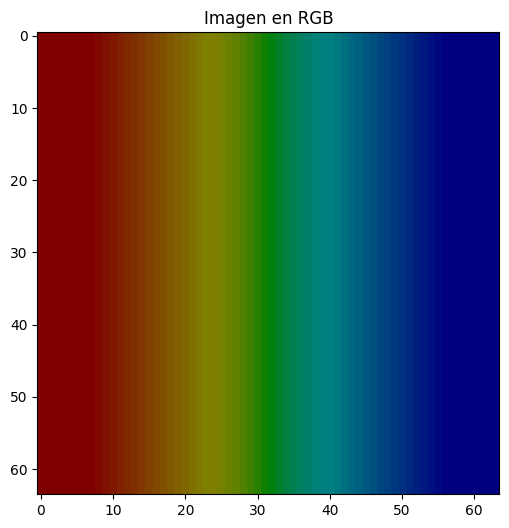

In [21]:
plt.figure(figsize=(12, 6))
plt.imshow(img_rgb)
plt.title('Imagen en RGB')
plt.show()

Tengo 3 canales donde:
- H, hue: tono del color. Open cv usa un rango de 0 a 180° y no a 360
- S: saturacion, va de 0 a 255 donde cero
- v: brillo, intensidad. 0 a 255

In [22]:
R, G, B = cv2.split(img_rgb)
H, S,V = cv2.split(img_hsv) #para separarlos
print(np.min(H), np.max(H))
print(np.min(S), np.max(S))
print(np.min(V), np.max(V))


0 120
255 255
128 128


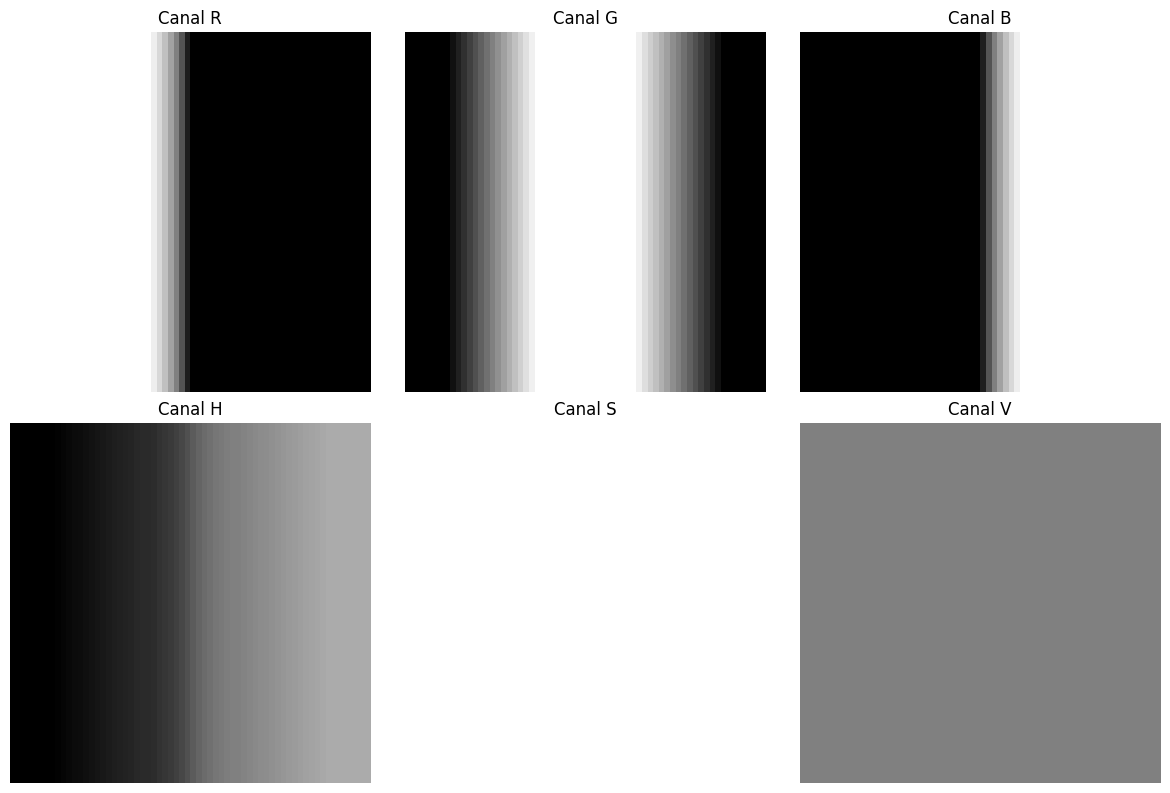

In [23]:
#graficar las matrices
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
# fila RGB
axs[0,0].imshow(R, cmap='gray')
axs[0,0].set_title("Canal R")

axs[0,1].imshow(G, cmap='gray')
axs[0,1].set_title("Canal G")

axs[0,2].imshow(B, cmap='gray')
axs[0,2].set_title("Canal B")

# fila HSV
axs[1,0].imshow(H, cmap='gray', vmin=0, vmax=179)
axs[1,0].set_title("Canal H")

axs[1,1].imshow(S, cmap='gray', vmin=0, vmax=255)
axs[1,1].set_title("Canal S")

axs[1,2].imshow(V, cmap='gray', vmin=0, vmax=255)
axs[1,2].set_title("Canal V")

# quitar ejes
for ax in axs.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

En HSV vemos que:
- El canal de tono va decayendo, rojo es 0 (negro) y va decayendo hasta el azul (aproximadamente el 120 que estuvimos viendo)
- El canal de saturación esta practicamente blanco, es decir, contiene valores de 255. Esto significa que los colores son totalmentes puros, sin mezclas de blancos.
- El canal de intensidad se ve a 128, intensidad casi a la mitad.

$$$$

El ejercició me pide que haga que H recorra el circulo desde azul hasta rojo, con saturación (ya está) y brillo maximo

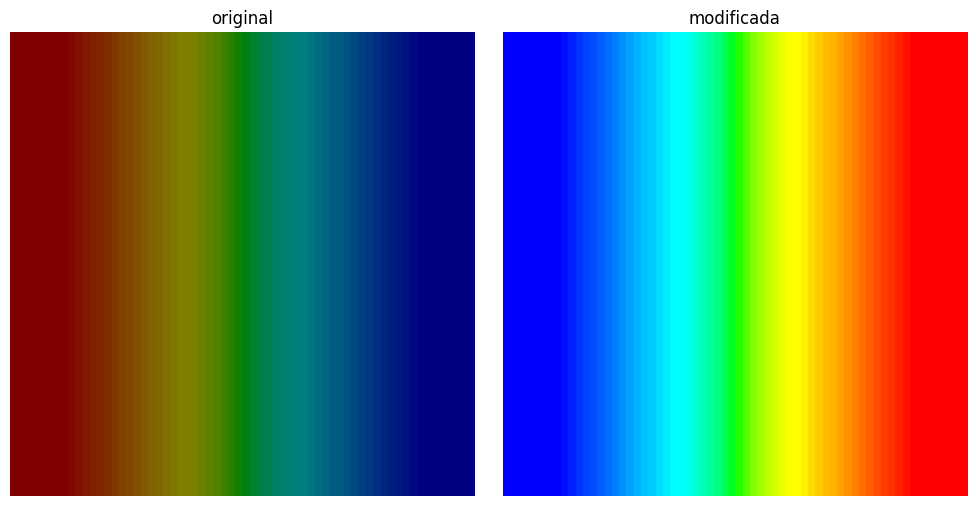

In [24]:
# subirle intensidad
V_new = np.ones_like(V)* 255
H_new = 120 - H

new_hsv = cv2.merge([H_new, S, V_new])

mostrar_horizontal(img_hsv, new_hsv, "original", "modificada")

para ver en tiempo real como inciden los efectos.
Podemos ver que:
- Independientemente de V, S=0 implica blanco (sin saturacion)
- Independientemente de S, V=0 implica negro (sin brillo)

In [25]:
slider_hsv(img_hsv)

interactive(children=(IntSlider(value=255, description='S', max=255), IntSlider(value=255, description='V', ma…

# parte 2 Rosas

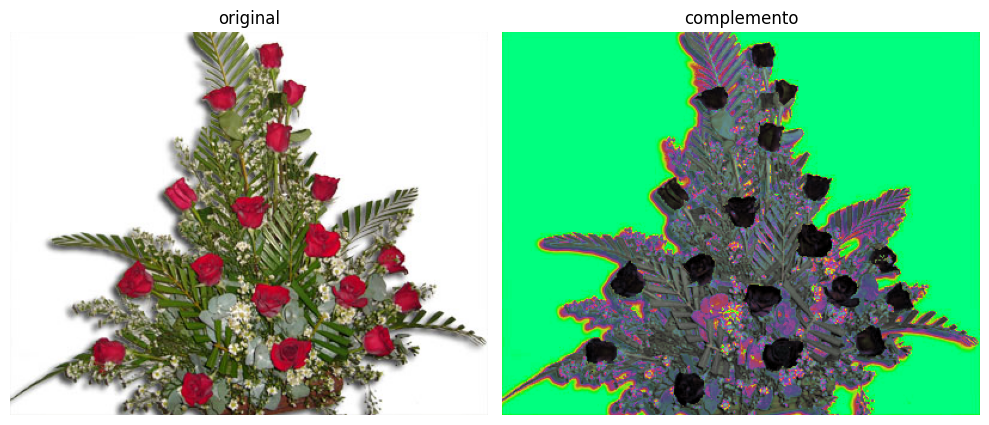

In [31]:
img = cv2.imread('../Imagenes_cursado/rosas.jpg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)


H, S, V = cv2.split(img_hsv)

H_new = (H + 90)%180 
new_hsv = cv2.merge([H_new, S, V])
new_rgb = cv2.cvtColor(new_hsv, cv2.COLOR_HSV2RGB)

mostrar_horizontal(img_hsv, new_rgb, "original", "complemento")

# Parte 3

Intensidad: 
- En HSV: es la primera columna
- En RGB: es el promedio

In [35]:
# Tomamos una linea de pixeles

def perfiles_color(img_rgb, img_hsv,fila):
    h = img_rgb.shape[0]
    R, G, B = cv2.split(img_rgb)
    H, S, V = cv2.split(img_hsv)


    perfil_R = R[fila, :]
    perfil_G = G[fila, :]
    perfil_B = B[fila, :]
    
    perfil_H = H[fila, :]
    perfil_S = S[fila, :]
    perfil_V = V[fila, :]
    fig, axs = plt.subplots(2, 3, figsize=(14,8))

    # RGB
    axs[0,0].plot(perfil_R, color='red')
    axs[0,0].set_title("Perfil R")
    axs[0,0].set_xlabel("Columna")
    axs[0,0].set_ylabel("Intensidad")
    axs[0,0].grid(True)

    axs[0,1].plot(perfil_G, color='green')
    axs[0,1].set_title("Perfil G")
    axs[0,1].set_xlabel("Columna")
    axs[0,1].set_ylabel("Intensidad")
    axs[0,1].grid(True)

    axs[0,2].plot(perfil_B, color='blue')
    axs[0,2].set_title("Perfil B")
    axs[0,2].set_xlabel("Columna")
    axs[0,2].set_ylabel("Intensidad")
    axs[0,2].grid(True)

    # HSV
    axs[1,0].plot(perfil_H)
    axs[1,0].set_title("Perfil H")
    axs[1,0].set_xlabel("Columna")
    axs[1,0].set_ylabel("Valor")
    axs[1,0].grid(True)

    axs[1,1].plot(perfil_S)
    axs[1,1].set_title("Perfil S")
    axs[1,1].set_xlabel("Columna")
    axs[1,1].set_ylabel("Valor")
    axs[1,1].grid(True)

    axs[1,2].plot(perfil_V)
    axs[1,2].set_title("Perfil V")
    axs[1,2].set_xlabel("Columna")
    axs[1,2].set_ylabel("Valor")
    axs[1,2].grid(True)

    plt.tight_layout()
    plt.show()


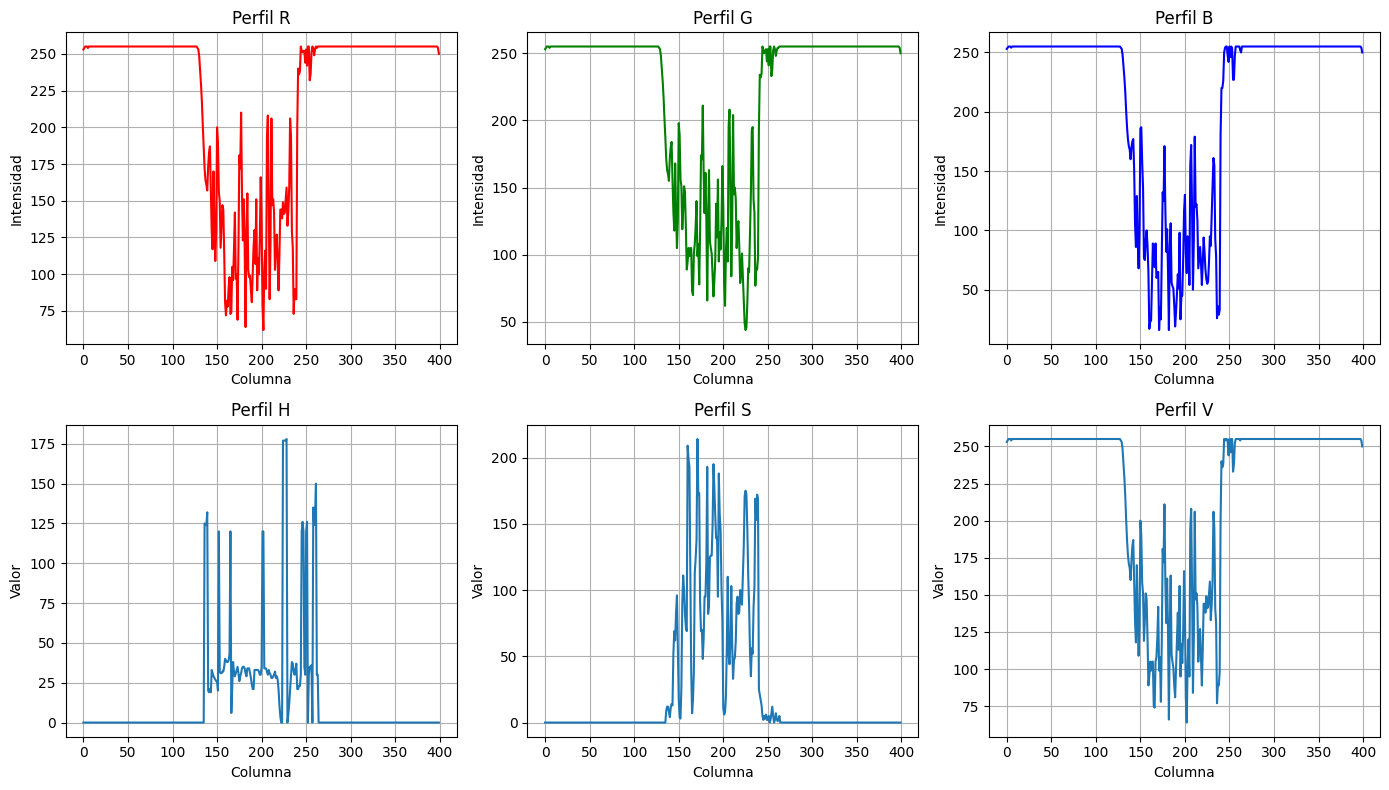

In [36]:
perfiles_color(img_rgb, img_hsv, fila=100)